In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## Loading dataset
df=pd.read_csv("german_credit_data (2).csv")

In [3]:
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [4]:
df.shape

(1000, 11)

In [5]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [6]:
df.iloc[:,:]
    

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [7]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [8]:
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,40,male,3,own,little,little,3857,30,car,good
997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [9]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [10]:
###Handling null values

In [11]:
for features in df.columns:
    print("the % of null in", features, sum(df[features].isnull())*100/1000)    

the % of null in Age 0.0
the % of null in Sex 0.0
the % of null in Job 0.0
the % of null in Housing 0.0
the % of null in Saving accounts 18.3
the % of null in Checking account 39.4
the % of null in Credit amount 0.0
the % of null in Duration 0.0
the % of null in Purpose 0.0
the % of null in Risk 0.0


In [12]:
df['Saving accounts'].fillna('unknown', inplace=True)
df['Checking account'].fillna('unknown', inplace=True)

/var/folders/4q/fkbn57gd6ll_zy09h5_np9dw0000gn/T/ipykernel_1592/1533544327.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Saving accounts'].fillna('unknown', inplace=True)
/var/folders/4q/fkbn57gd6ll_zy09h5_np9dw0000gn/T/ipykernel_1592/1533544327.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

In [13]:
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,unknown,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,unknown,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,unknown,1736,12,furniture/equipment,good
996,40,male,3,own,little,little,3857,30,car,good
997,38,male,2,own,little,unknown,804,12,radio/TV,good
998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [14]:
df['Saving accounts'].value_counts()

Saving accounts
little        603
unknown       183
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64

In [15]:
df['Checking account'].value_counts()

Checking account
unknown     394
little      274
moderate    269
rich         63
Name: count, dtype: int64

In [16]:
df.dtypes

Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
Risk                object
dtype: object

In [17]:
df['Risk'] = df['Risk'].map({'good': 1, 'bad': 0})

In [18]:
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,unknown,little,1169,6,radio/TV,1
1,22,female,2,own,little,moderate,5951,48,radio/TV,0
2,49,male,1,own,little,unknown,2096,12,education,1
3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,53,male,2,free,little,little,4870,24,car,0
...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,unknown,1736,12,furniture/equipment,1
996,40,male,3,own,little,little,3857,30,car,1
997,38,male,2,own,little,unknown,804,12,radio/TV,1
998,23,male,2,free,little,little,1845,45,radio/TV,0


In [19]:
df['Risk'].value_counts(normalize=True)

Risk
1    0.7
0    0.3
Name: proportion, dtype: float64

In [20]:
## Encode categorical variables

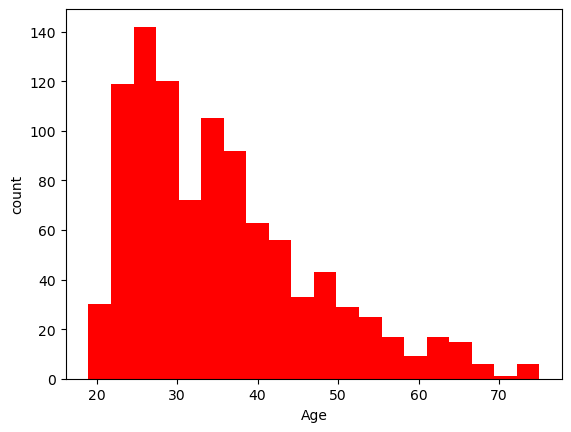

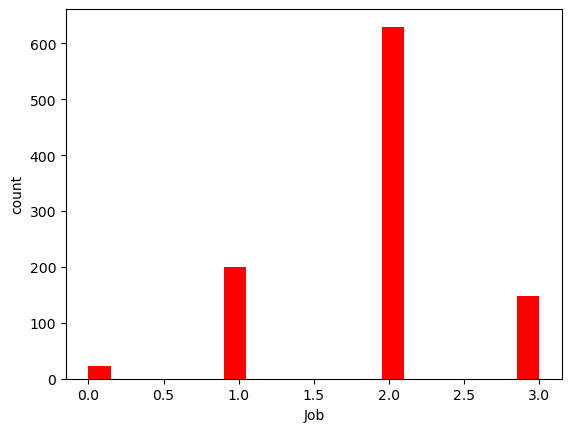

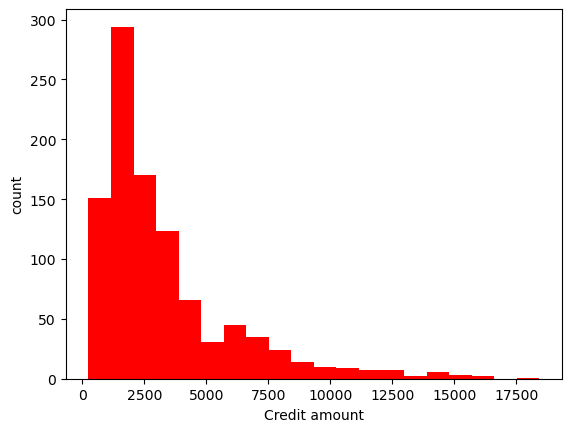

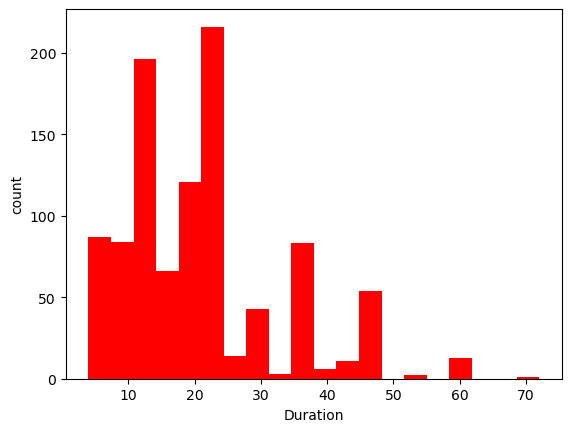

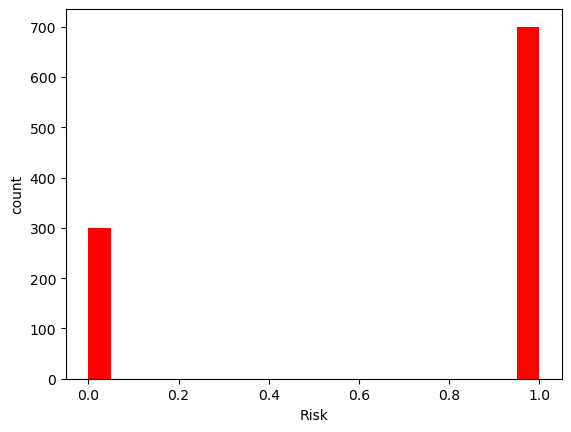

In [22]:
for features in df.columns:
    if df[features].dtypes!='O':
        plt.hist(df[features], bins=20, color='red')
        plt.xlabel(features)
        plt.ylabel("count")
        plt.show()
        
        
   

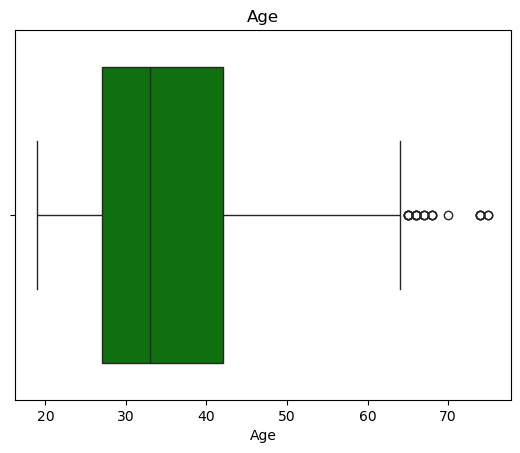

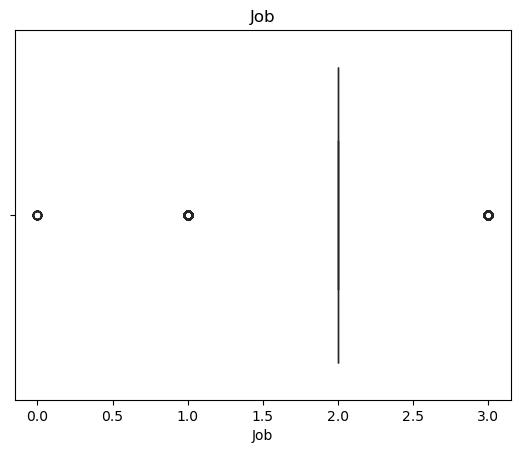

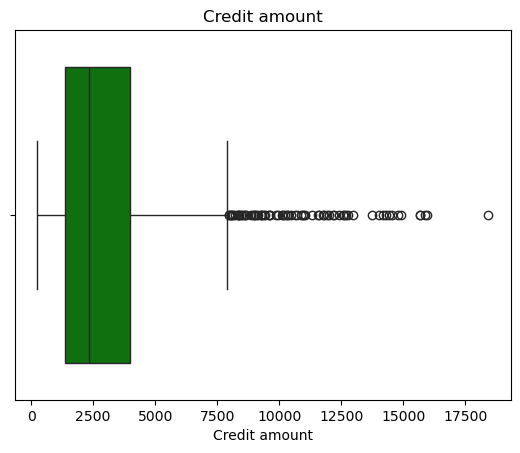

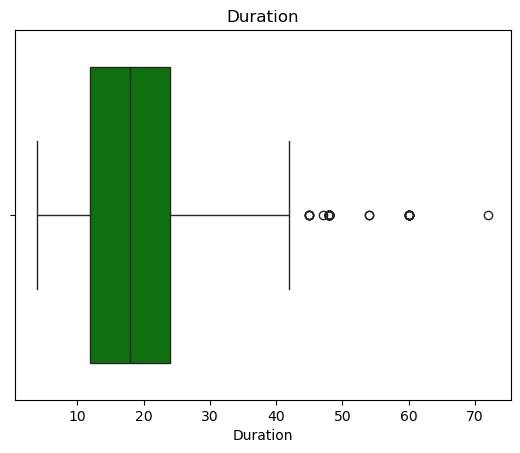

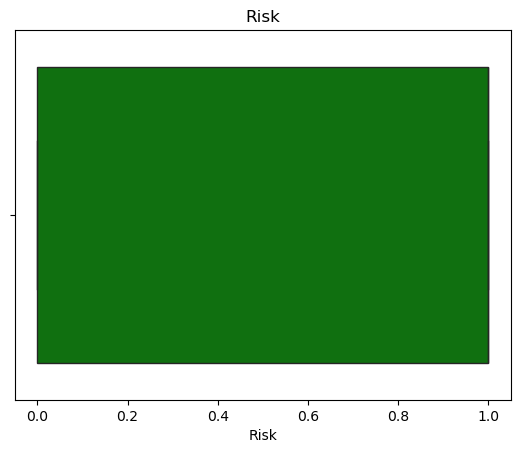

In [23]:
## outlier 
for feature in df.columns:
    if df[feature].dtypes!='O':
        plt.figure()
        sns.boxplot(x=df[feature], color='green')
        plt.title(feature)
        plt.show()

In [ ]:
###Encoding Target variable

In [24]:
cat_var=[]
for feature in df.columns:
    if df[feature].dtypes=='O':
        cat_var.append(feature)
        

In [25]:
df=pd.get_dummies(df, columns=cat_var, drop_first=True)

In [26]:
df

,Age,Job,Credit amount,Duration,Risk,Sex_male,Housing_own,Housing_rent,Saving accounts_moderate,Saving accounts_quite rich,...,Checking account_moderate,Checking account_rich,Checking account_unknown,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,2,1169,6,1,True,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,22,2,5951,48,0,False,True,False,False,False,...,True,False,False,False,False,False,False,True,False,False
2,49,1,2096,12,1,True,True,False,False,False,...,False,False,True,False,False,True,False,False,False,False
3,45,2,7882,42,1,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,53,2,4870,24,0,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31,1,1736,12,1,False,True,False,False,False,...,False,False,True,False,False,False,True,False,False,False
996,40,3,3857,30,1,True,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False
997,38,2,804,12,1,True,True,False,False,False,...,False,False,True,False,False,False,False,True,False,False
998,23,2,1845,45,0,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [27]:
df.columns

Index(['Age', 'Job', 'Credit amount', 'Duration', 'Risk', 'Sex_male',
       'Housing_own', 'Housing_rent', 'Saving accounts_moderate',
       'Saving accounts_quite rich', 'Saving accounts_rich',
       'Saving accounts_unknown', 'Checking account_moderate',
       'Checking account_rich', 'Checking account_unknown', 'Purpose_car',
       'Purpose_domestic appliances', 'Purpose_education',
       'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs',
       'Purpose_vacation/others'],
      dtype='object')

In [28]:
len(df.columns)

22

In [ ]:
## Addressing skewness

In [29]:
import numpy as np

# Applying log transformation to Credit amount
df['Credit amount'] = np.log(df['Credit amount'])
df['Age'] = np.log(df['Age'])



<Axes: xlabel='Credit amount', ylabel='Count'>

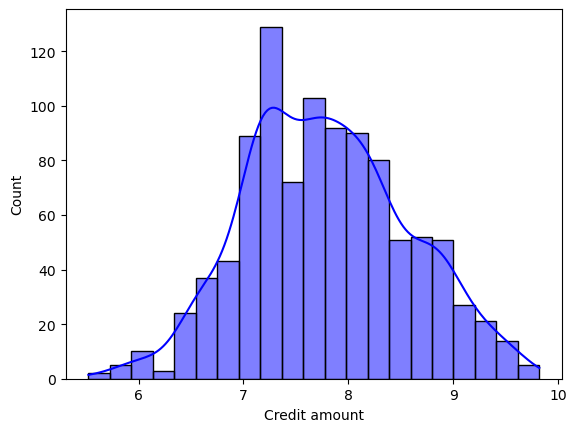

In [30]:
# Visualize again to see the improvement
sns.histplot(df['Credit amount'], kde=True, color='blue')

<Axes: xlabel='Age', ylabel='Count'>

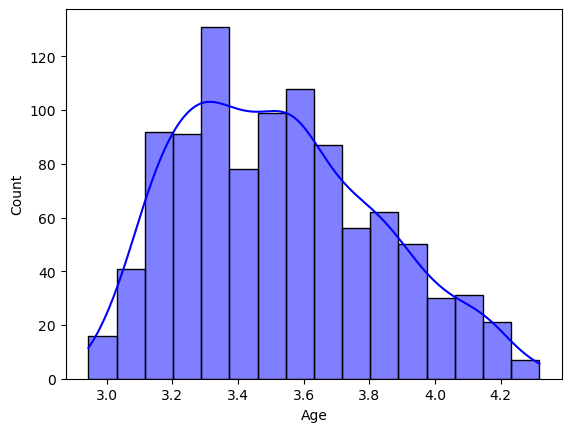

In [31]:
sns.histplot(df['Age'], kde=True, color='blue')

In [ ]:
## Train test split

In [32]:
from sklearn.model_selection import train_test_split

y = df['Risk']
X = df.drop('Risk', axis=1)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

Training shape: (800, 21)
Testing shape: (200, 21)


In [ ]:
### Feature scaling

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# List of numerical columns to scale
num_cols = ['Age', 'Credit amount', 'Duration', 'Job']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train.head()

,Age,Job,Credit amount,Duration,Sex_male,Housing_own,Housing_rent,Saving accounts_moderate,Saving accounts_quite rich,Saving accounts_rich,...,Checking account_moderate,Checking account_rich,Checking account_unknown,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
29,2.060750,0.107048,1.309515,3.297082,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
535,-0.093103,0.107048,-0.085359,-0.008051,True,False,True,False,False,False,...,False,True,False,False,False,True,False,False,False,False
695,1.290939,0.107048,-0.897272,-1.279256,True,False,True,False,True,False,...,False,False,True,True,False,False,False,False,False,False
557,-0.523494,0.107048,0.906736,-0.008051,False,True,False,False,False,False,...,False,False,True,True,False,False,False,False,False,False
836,-1.598622,0.107048,-1.326829,-0.770774,False,True,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False


In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initialize the model
# We use class_weight='balanced' because your 'Bad' risk class is smaller
model1 = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Fit the model using the scaled training data
model1.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
# Predict on the test set
y_pred = model1.predict(X_test)

# Check the results
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Confusion Matrix ---
[[ 25  34]
 [ 16 125]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.61      0.42      0.50        59
           1       0.79      0.89      0.83       141

    accuracy                           0.75       200
   macro avg       0.70      0.66      0.67       200
weighted avg       0.73      0.75      0.73       200



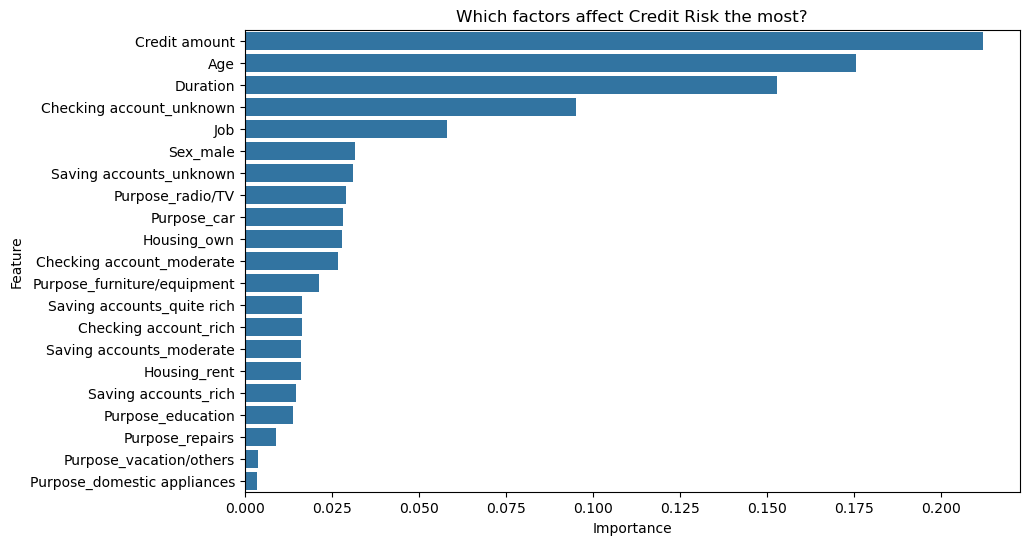

In [36]:
import matplotlib.pyplot as plt

# Get feature importances
importances = model1.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Which factors affect Credit Risk the most?')
plt.show()

In [ ]:
### USING SMOTE AND CHECKING

In [37]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

model2 = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Now train your RandomForest on X_train_res and y_train_res
model2.fit(X_train_res, y_train_res)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
# Predict on the test set
y_pred = model2.predict(X_test)

# Check the results
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Confusion Matrix ---
[[ 29  30]
 [ 29 112]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.50      0.49      0.50        59
           1       0.79      0.79      0.79       141

    accuracy                           0.70       200
   macro avg       0.64      0.64      0.64       200
weighted avg       0.70      0.70      0.70       200



In [ ]:
### REMOVING UNIMPORTANT VARIABLES

In [39]:
importances = model2.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)


In [40]:
feature_importance_df

,Feature,Importance
2,Credit amount,0.202845
3,Duration,0.180136
0,Age,0.179194
13,Checking account_unknown,0.075335
1,Job,0.059960
10,Saving accounts_unknown,0.030508
14,Purpose_car,0.030314
11,Checking account_moderate,0.028716
4,Sex_male,0.027545
18,Purpose_radio/TV,0.027166


In [41]:
final_features = feature_importance_df[feature_importance_df['Importance']>0.01]

In [42]:
final_features

,Feature,Importance
2,Credit amount,0.202845
3,Duration,0.180136
0,Age,0.179194
13,Checking account_unknown,0.075335
1,Job,0.059960
10,Saving accounts_unknown,0.030508
14,Purpose_car,0.030314
11,Checking account_moderate,0.028716
4,Sex_male,0.027545
18,Purpose_radio/TV,0.027166


In [59]:
final_features_list=list(final_features['Feature'])

In [60]:
final_features_list

['Credit amount',
 'Duration',
 'Age',
 'Checking account_unknown',
 'Job',
 'Saving accounts_unknown',
 'Purpose_car',
 'Checking account_moderate',
 'Sex_male',
 'Purpose_radio/TV',
 'Housing_own',
 'Housing_rent',
 'Saving accounts_moderate',
 'Purpose_furniture/equipment',
 'Purpose_education',
 'Saving accounts_quite rich',
 'Saving accounts_rich',
 'Checking account_rich']

In [61]:
final_features_list_with_target = final_features_list+['Risk']

In [62]:
print(final_features_list_with_target)

['Credit amount', 'Duration', 'Age', 'Checking account_unknown', 'Job', 'Saving accounts_unknown', 'Purpose_car', 'Checking account_moderate', 'Sex_male', 'Purpose_radio/TV', 'Housing_own', 'Housing_rent', 'Saving accounts_moderate', 'Purpose_furniture/equipment', 'Purpose_education', 'Saving accounts_quite rich', 'Saving accounts_rich', 'Checking account_rich', 'Risk']


In [63]:
df2=df[final_features_list_with_target]

In [64]:
df2

,Credit amount,Duration,Age,Checking account_unknown,Job,Saving accounts_unknown,Purpose_car,Checking account_moderate,Sex_male,Purpose_radio/TV,Housing_own,Housing_rent,Saving accounts_moderate,Purpose_furniture/equipment,Purpose_education,Saving accounts_quite rich,Saving accounts_rich,Checking account_rich,Risk
0,7.063904,6,4.204693,False,2,True,False,False,True,True,True,False,False,False,False,False,False,False,1
1,8.691315,48,3.091042,False,2,False,False,True,False,True,True,False,False,False,False,False,False,False,0
2,7.647786,12,3.891820,True,1,False,False,False,True,False,True,False,False,False,True,False,False,False,1
3,8.972337,42,3.806662,False,2,False,False,False,True,False,False,False,False,True,False,False,False,False,1
4,8.490849,24,3.970292,False,2,False,True,False,True,False,False,False,False,False,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,7.459339,12,3.433987,True,1,False,False,False,False,False,True,False,False,True,False,False,False,False,1
996,8.257645,30,3.688879,False,3,False,True,False,True,False,True,False,False,False,False,False,False,False,1
997,6.689599,12,3.637586,True,2,False,False,False,True,True,True,False,False,False,False,False,False,False,1
998,7.520235,45,3.135494,False,2,False,False,False,True,True,False,False,False,False,False,False,False,False,0


In [ ]:
##again testing

In [65]:
from sklearn.model_selection import train_test_split

y = df2['Risk']
X = df2.drop('Risk', axis=1)


X_train_imp_fea, X_test_imp_fea, y_train_imp_fea, y_test_imp_fea = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training shape: {X_train_imp_fea.shape}")
print(f"Testing shape: {X_test_imp_fea.shape}")

Training shape: (800, 18)
Testing shape: (200, 18)


In [ ]:
##using SMOTE

In [66]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_imp_fea, y_train_imp_fea = sm.fit_resample(X_train_imp_fea, y_train_imp_fea)



In [67]:
print(f"Training shape: {X_train_imp_fea.shape}")
print(f"Testing shape: {X_test_imp_fea.shape}")

Training shape: (1118, 18)
Testing shape: (200, 18)


In [71]:
y_train_imp_fea.value_counts()

Risk
0    559
1    559
Name: count, dtype: int64

In [ ]:
##Fitting model3

In [72]:
model3 = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Now train your RandomForest on X_train_res and y_train_res
model3.fit(X_train_imp_fea, y_train_imp_fea)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [74]:
# Predict on the test set
y_pred = model3.predict(X_test_imp_fea)

# Check the results
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test_imp_fea, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_test_imp_fea, y_pred))

--- Confusion Matrix ---
[[ 34  25]
 [ 28 113]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.55      0.58      0.56        59
           1       0.82      0.80      0.81       141

    accuracy                           0.73       200
   macro avg       0.68      0.69      0.69       200
weighted avg       0.74      0.73      0.74       200



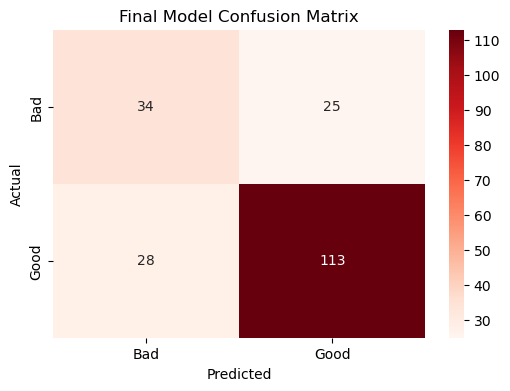

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_imp_fea, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Model Confusion Matrix')
plt.show()

In [76]:
# 1. Get the probability of the 'Bad' class (class 0)
# predict_proba returns [prob_of_0, prob_of_1]
y_probs = model3.predict_proba(X_test_imp_fea)[:, 0]

# 2. Lower the threshold from 0.5 to 0.4 
# (Meaning: If there's even a 40% chance they are "Bad", we label them "Bad")
new_threshold = 0.4
y_pred_aggressive = (y_probs >= new_threshold).astype(int)

# Note: We need to flip the logic to match your 'Risk' encoding 
# If your 'Bad' is 0 and 'Good' is 1:
y_pred_final = 1 - y_pred_aggressive 

from sklearn.metrics import classification_report, confusion_matrix
print("--- Aggressive Model Results ---")
print(classification_report(y_test_imp_fea, y_pred_final))

--- Aggressive Model Results ---
              precision    recall  f1-score   support

           0       0.47      0.69      0.56        59
           1       0.84      0.67      0.75       141

    accuracy                           0.68       200
   macro avg       0.66      0.68      0.65       200
weighted avg       0.73      0.68      0.69       200



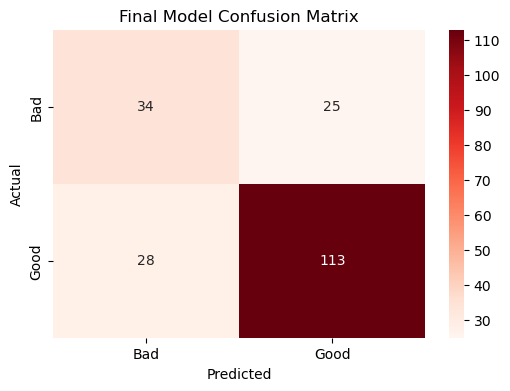

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_imp_fea, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Model Confusion Matrix')
plt.show()

In [ ]:
import joblib

# Save the model
joblib.dump(model3, 'credit_risk_model.pkl')

# Save the column names so you know which 18 features to use in the app
joblib.dump(final_features_list, 'feature_names.pkl')

In [78]:
import joblib

# Save the model
joblib.dump(model3, 'credit_risk_model.pkl')

# Save the column names so you know which 18 features to use in the app
joblib.dump(final_features_list, 'feature_names.pkl')

['feature_names.pkl']

In [79]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 18.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shap]


In [99]:
import shap

# 1. Create a SHAP explainer specifically for Tree-based models
explainer = shap.TreeExplainer(model3)

# 2. Calculate SHAP values for your test set
# We use the test set with the 18 important features
shap_values = explainer.shap_values(X_test_imp_fea)

IndexError: tuple index out of range

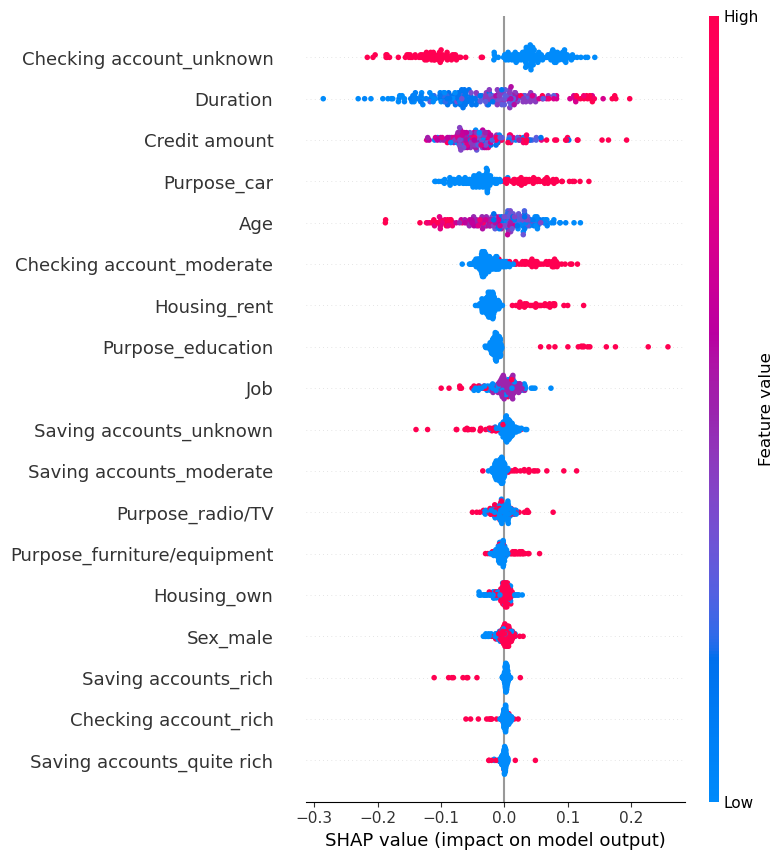

In [103]:
import shap

# 1. Slice the 3D array (200, 18, 2) into a 2D array (200, 18)
# We take all rows (:), all features (:), and the 0th index of the classes (0)
correct_shap_matrix = shap_values[:, :, 0]

# 2. Now pass the 2D matrix and your feature DataFrame
shap.summary_plot(correct_shap_matrix, X_test_imp_fea)

In [101]:
correct_shap_matrix

array([[-1.00821789e-01, -3.83190524e-02,  2.28684310e-03, ...,
         2.00917493e-03,  5.86998396e-03, -5.72500851e-04],
       [-5.10857451e-02, -1.43949728e-02,  1.22039640e-03, ...,
        -7.89293231e-05,  2.77762881e-03,  3.89951685e-03],
       [-7.98984746e-02,  1.62993301e-02,  3.76085498e-02, ...,
        -1.22478481e-04,  3.60844152e-03,  6.59920836e-03],
       ...,
       [-4.11230787e-03, -4.58633185e-03, -5.99866096e-03, ...,
        -6.92801337e-04,  3.52070953e-03,  5.42461128e-03],
       [-1.22659943e-01,  4.80623424e-02,  3.99142024e-02, ...,
         2.71064945e-04,  9.14467925e-03,  8.28906959e-03],
       [ 2.42429986e-02,  1.36279613e-01,  1.20218345e-03, ...,
        -3.19120727e-03,  2.17802752e-03,  1.10185632e-03]],
      shape=(200, 18))

In [83]:
 X_test_imp_fea

,Credit amount,Duration,Age,Checking account_unknown,Job,Saving accounts_unknown,Purpose_car,Checking account_moderate,Sex_male,Purpose_radio/TV,Housing_own,Housing_rent,Saving accounts_moderate,Purpose_furniture/equipment,Purpose_education,Saving accounts_quite rich,Saving accounts_rich,Checking account_rich
521,8.067776,18,3.178054,False,2,False,False,False,False,True,True,False,False,False,False,False,False,False
737,8.384804,18,3.555348,False,1,False,True,False,True,False,True,False,True,False,False,False,False,False
740,7.751475,24,3.465736,False,2,False,True,False,True,False,True,False,True,False,False,False,False,False
660,7.167809,12,3.135494,False,2,False,False,False,True,True,False,True,False,False,False,False,False,True
411,8.889170,33,3.555348,True,3,False,True,False,True,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,8.081784,24,3.258097,True,3,False,False,False,True,True,True,False,False,False,False,True,False,False
332,8.910316,60,3.178054,False,3,False,True,True,False,False,True,False,True,False,False,False,False,False
208,8.789965,24,3.044522,False,1,False,False,False,True,False,True,False,False,False,False,False,False,False
613,8.197539,24,3.091042,False,2,False,True,False,False,False,False,True,False,False,False,False,False,False


In [105]:
 X_test_imp_fea.columns

Index(['Credit amount', 'Duration', 'Age', 'Checking account_unknown', 'Job',
       'Saving accounts_unknown', 'Purpose_car', 'Checking account_moderate',
       'Sex_male', 'Purpose_radio/TV', 'Housing_own', 'Housing_rent',
       'Saving accounts_moderate', 'Purpose_furniture/equipment',
       'Purpose_education', 'Saving accounts_quite rich',
       'Saving accounts_rich', 'Checking account_rich'],
      dtype='object')

In [111]:
 X_test_imp_fea['Checking account_unknown'].value_counts()

Checking account_unknown
False    129
True      71
Name: count, dtype: int64

In [113]:
X_test_false=X_test_imp_fea[X_test_imp_fea['Checking account_unknown']==False]

In [114]:
X_test_false

,Credit amount,Duration,Age,Checking account_unknown,Job,Saving accounts_unknown,Purpose_car,Checking account_moderate,Sex_male,Purpose_radio/TV,Housing_own,Housing_rent,Saving accounts_moderate,Purpose_furniture/equipment,Purpose_education,Saving accounts_quite rich,Saving accounts_rich,Checking account_rich
521,8.067776,18,3.178054,False,2,False,False,False,False,True,True,False,False,False,False,False,False,False
737,8.384804,18,3.555348,False,1,False,True,False,True,False,True,False,True,False,False,False,False,False
740,7.751475,24,3.465736,False,2,False,True,False,True,False,True,False,True,False,False,False,False,False
660,7.167809,12,3.135494,False,2,False,False,False,True,True,False,True,False,False,False,False,False,True
678,7.776535,24,4.158883,False,1,False,False,False,True,True,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,8.365672,18,3.688879,False,3,False,False,True,True,False,True,False,False,True,False,False,False,False
213,7.553811,30,4.189655,False,3,False,False,False,True,False,True,False,False,False,False,False,False,True
332,8.910316,60,3.178054,False,3,False,True,True,False,False,True,False,True,False,False,False,False,False
208,8.789965,24,3.044522,False,1,False,False,False,True,False,True,False,False,False,False,False,False,False


In [115]:
pred=model3.predict( X_test_false)

In [116]:
pred

array([1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0])

In [124]:
print("Number of Good Risks (1):", (pred == 1).sum())
print("Number of Bad Risks (0):", (pred == 0).sum())

Number of Good Risks (1): 75
Number of Bad Risks (0): 54


In [125]:
X_test_true=X_test_imp_fea[X_test_imp_fea['Checking account_unknown']==True]

In [127]:
pred2=model3.predict( X_test_true)

In [128]:
print("Number of Good Risks (1):", (pred2 == 1).sum())
print("Number of Bad Risks (0):", (pred2 == 0).sum())

Number of Good Risks (1): 63
Number of Bad Risks (0): 8


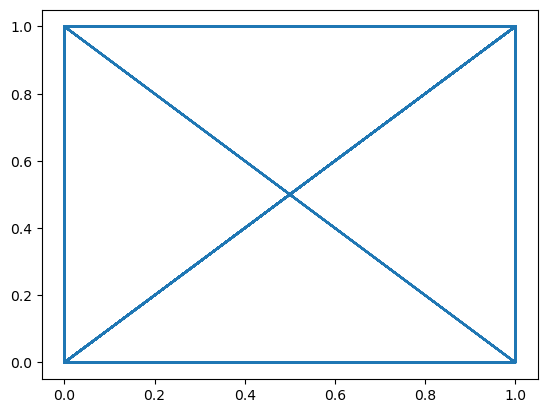

In [109]:
plt.plot(X_test_imp_fea['Checking account_unknown'],pred)

In [84]:
 len(X_test_imp_fea.columns)

18

In [87]:
shap_values

array([[[-1.00821789e-01,  1.00821789e-01],
        [-3.83190524e-02,  3.83190524e-02],
        [ 2.28684310e-03, -2.28684310e-03],
        ...,
        [ 2.00917493e-03, -2.00917493e-03],
        [ 5.86998396e-03, -5.86998396e-03],
        [-5.72500851e-04,  5.72500851e-04]],

       [[-5.10857451e-02,  5.10857451e-02],
        [-1.43949728e-02,  1.43949728e-02],
        [ 1.22039640e-03, -1.22039640e-03],
        ...,
        [-7.89293231e-05,  7.89293231e-05],
        [ 2.77762881e-03, -2.77762881e-03],
        [ 3.89951685e-03, -3.89951685e-03]],

       [[-7.98984746e-02,  7.98984746e-02],
        [ 1.62993301e-02, -1.62993301e-02],
        [ 3.76085498e-02, -3.76085498e-02],
        ...,
        [-1.22478481e-04,  1.22478481e-04],
        [ 3.60844152e-03, -3.60844152e-03],
        [ 6.59920836e-03, -6.59920836e-03]],

       ...,

       [[-4.11230787e-03,  4.11230787e-03],
        [-4.58633185e-03,  4.58633185e-03],
        [-5.99866096e-03,  5.99866096e-03],
        ...,
     

In [131]:
import joblib

# Replace 'scaler' with whatever name you gave your scaler object
# If you didn't use a scaler, you can skip this!
metadata = {
    'model': model3,
    'features': list(X_test_imp_fea.columns),
    'scaler': scaler,  # Add your scaler here
    'threshold': 0.4
}

# Save everything into one file
joblib.dump(metadata, 'final_credit_model_package.pkl')
print("Model, Features, and Scaler saved successfully!")

Model, Features, and Scaler saved successfully!
